In [2]:
import pandas as pd
import miceforest as mf
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

In [3]:
os.chdir(r'T:\lab_research\RES-Folder-UPOD\ODIN-UC4\E_ResearchData\2_ResearchData\20240805')

In [4]:
df_lab = pd.read_parquet('lab_20240805.parquet')
df_lab.studyId_0831 = df_lab.studyId_0831.astype(int)

In [5]:
df_lab.columns # How many of those are relevant to us?

Index(['studyId_0831', 'identifier_value', 'basedOn_ProcedureRequest_value',
       'LabID', 'category3_display_original', 'category4_code_original',
       'code_code_original', 'code_display_original', 'code2_code_original',
       'code2_display_original', 'code3_display_original',
       'code3_system_original', 'code4_display_original', 'comment',
       'effectiveDateTime', 'interpretation_display', 'referenceRange_text',
       'status_display_original', 'valueQuantity_code_original',
       'valueQuantity_comparator', 'valueQuantity_unit',
       'valueQuantity_unit_original', 'valueQuantity_value', 'valueString',
       'Practitioner_Rol', 'gender', 'organization_Organization_value',
       'specialty_specialtyAGB_display', 'index_date'],
      dtype='object')

In [6]:
units = df_lab.groupby('code_display_original').last(
).valueQuantity_code_original.to_list()

Let's remove uneuseful columns

In [7]:
df_lab = df_lab.drop(['identifier_value', 'basedOn_ProcedureRequest_value',
                      'LabID', 'category3_display_original', 'category4_code_original',
                      'code_code_original', 'code2_code_original',
                      'code2_display_original', 'code3_display_original',
                      'interpretation_display',
                      'code3_system_original', 'code4_display_original', 'comment',
                      'status_display_original',
                      'valueQuantity_comparator', 'valueQuantity_unit',
                      'valueQuantity_unit_original', 'valueString',
                      'Practitioner_Rol', 'gender', 'organization_Organization_value',
                      'specialty_specialtyAGB_display', 'index_date'], axis='columns')

Storing the reference range of values per substance

In [8]:
substances = pd.read_excel(
    r'T:\lab_research\RES-Folder-UPOD\ODIN-UC4\G_Output\2_Data\excel\measurements_ranges.xlsx')
substances = substances.set_index('substance')


substances.loc['Kreatinine']['unit']

'µmol/L'

Pivoting on the chemical sub

In [9]:
df_lab

,studyId_0831,code_display_original,effectiveDateTime,referenceRange_text,valueQuantity_code_original,valueQuantity_value
0,27942639753,Kreatinine,2022-10-21 11:41:00,49 - 90,µmol/L,70.0
1,27942639753,Kalium,2022-10-21 11:41:00,3.8 - 5.0,mmol/L,4.2
2,27942639753,Natrium,2022-10-21 11:41:00,136 - 146,mmol/L,143.0
3,27942639753,Hemoglobine,2022-10-21 11:41:00,7.4 - 9.6,mmol/L,9.0
4,27942639753,eGFR (CKD-EPI),2022-10-21 11:41:00,80 -,mL/min/1.73m2,76.0
...,...,...,...,...,...,...
139585,18941233745,Kreatinine,2021-11-24 13:29:00,49 - 90,µmol/L,45.0
139586,18941233745,Kalium,2021-11-24 13:29:00,3.8 - 5.0,mmol/L,3.8
139587,18941233745,Natrium,2021-11-24 13:29:00,136 - 146,mmol/L,136.0
139588,18941233745,Hemoglobine,2021-11-24 13:29:00,7.4 - 9.6,mmol/L,8.7


In [24]:
df_lab.pivot(columns='code_display_original', values='valueQuantity_value').notna().sum()

code_display_original
CRP                    11669
Cholesterol             2525
HDL Cholesterol         2493
HbA1c                   2803
Hemoglobine            23126
Kalium                 23488
Kreatinine             21205
LDL Cholesterol         2147
Natrium                20724
Triglyceriden           2626
eGFR (CKD-EPI)         21181
non-HDL cholesterol     2481
dtype: int64

---
To be interpolated data

In [10]:
tb_interp = df_lab\
    .query('code_display_original in ["Kreatinine", "eGFR (CKD-EPI)","Natrium","Kalium","Hemoglobine"]')
tb_interp

,studyId_0831,code_display_original,effectiveDateTime,referenceRange_text,valueQuantity_code_original,valueQuantity_value
0,27942639753,Kreatinine,2022-10-21 11:41:00,49 - 90,µmol/L,70.0
1,27942639753,Kalium,2022-10-21 11:41:00,3.8 - 5.0,mmol/L,4.2
2,27942639753,Natrium,2022-10-21 11:41:00,136 - 146,mmol/L,143.0
3,27942639753,Hemoglobine,2022-10-21 11:41:00,7.4 - 9.6,mmol/L,9.0
4,27942639753,eGFR (CKD-EPI),2022-10-21 11:41:00,80 -,mL/min/1.73m2,76.0
...,...,...,...,...,...,...
139585,18941233745,Kreatinine,2021-11-24 13:29:00,49 - 90,µmol/L,45.0
139586,18941233745,Kalium,2021-11-24 13:29:00,3.8 - 5.0,mmol/L,3.8
139587,18941233745,Natrium,2021-11-24 13:29:00,136 - 146,mmol/L,136.0
139588,18941233745,Hemoglobine,2021-11-24 13:29:00,7.4 - 9.6,mmol/L,8.7


In [11]:
tb_interp_p = tb_interp.pivot(columns='code_display_original', values='valueQuantity_value')
tb_interp_p['studyId_0831'] = tb_interp.studyId_0831
tb_interp_p

code_display_original,Hemoglobine,Kalium,Kreatinine,Natrium,eGFR (CKD-EPI),studyId_0831
0,NaN,NaN,70.0,NaN,NaN,27942639753
1,NaN,4.2,NaN,NaN,NaN,27942639753
2,NaN,NaN,NaN,143.0,NaN,27942639753
3,9.0,NaN,NaN,NaN,NaN,27942639753
4,NaN,NaN,NaN,NaN,76.0,27942639753
...,...,...,...,...,...,...
139585,NaN,NaN,45.0,NaN,NaN,18941233745
139586,NaN,3.8,NaN,NaN,NaN,18941233745
139587,NaN,NaN,NaN,136.0,NaN,18941233745
139588,8.7,NaN,NaN,NaN,NaN,18941233745


In [12]:
def interp_and_wavg(x : pd.Series):
    if x.count() == 1:
        return x.fillna(0).sum()
    elif x.count() > 1:
        x = x.interpolate('from_derivatives')
        weights = np.linspace(0,1,len(x))
        return np.average(x.values,weights=weights)
    else:
        return np.nan

In [13]:
tb_interp_p = tb_interp_p.groupby('studyId_0831').agg(interp_and_wavg)
tb_interp_p

code_display_original,Hemoglobine,Kalium,Kreatinine,Natrium,eGFR (CKD-EPI)
studyId_0831,,,,,
7992019,NaN,NaN,NaN,NaN,NaN
9812359,NaN,NaN,NaN,NaN,NaN
22291801,NaN,NaN,66.0,NaN,88.0
29822615,7.3,4.7,68.0,142.0,74.0
52529671,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
67374258279,NaN,NaN,NaN,NaN,NaN
67384735347,NaN,NaN,NaN,NaN,NaN
67387668117,NaN,NaN,NaN,NaN,NaN


In [25]:
tb_interp_p.notna().sum()

code_display_original
Hemoglobine       1341
Kalium            1224
Kreatinine        1420
Natrium           1218
eGFR (CKD-EPI)    1549
dtype: int64

---
To be imputed data

In [16]:
tb_imputed = df_lab\
    .query('code_display_original not in ["Kreatinine", "eGFR (CKD-EPI)","Natrium","Kalium","Hemoglobine"]')
tb_imputed

,studyId_0831,code_display_original,effectiveDateTime,referenceRange_text,valueQuantity_code_original,valueQuantity_value
5,27933490859,CRP,2021-09-01 12:38:00,0 - 10,mg/L,7.00
19,27730388109,Cholesterol,2022-07-04 13:00:00,3.5 - 6.5,mmol/L,5.10
20,27730388109,Cholesterol,2022-07-04 13:00:00,3.5 - 6.5,mmol/L,5.10
21,27730388109,HDL Cholesterol,2022-07-04 13:00:00,1.10 -,mmol/L,1.81
22,27730388109,HDL Cholesterol,2022-07-04 13:00:00,1.10 -,mmol/L,1.81
...,...,...,...,...,...,...
139547,18903323479,HbA1c,2020-12-07 11:02:00,20 - 42,mmol/mol,38.00
139550,18903323479,CRP,2021-04-30 14:10:00,0 - 10,mg/L,9.00
139556,18903323479,HbA1c,2021-05-02 20:00:00,20 - 42,mmol/mol,27.00
139577,18903323479,HbA1c,2021-05-04 07:42:00,20 - 42,mmol/mol,27.00


In [28]:
tb_imputed_p = tb_imputed.pivot(
    columns='code_display_original', values='valueQuantity_value')
tb_imputed_p['studyId_0831'] = tb_imputed.studyId_0831
tb_imputed_p = tb_imputed_p.reset_index(drop=True)
tb_imputed_p

code_display_original,CRP,Cholesterol,HDL Cholesterol,HbA1c,LDL Cholesterol,Triglyceriden,non-HDL cholesterol,studyId_0831
0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,27933490859
1,NaN,5.1,NaN,NaN,NaN,NaN,NaN,27730388109
2,NaN,5.1,NaN,NaN,NaN,NaN,NaN,27730388109
3,NaN,NaN,1.81,NaN,NaN,NaN,NaN,27730388109
4,NaN,NaN,1.81,NaN,NaN,NaN,NaN,27730388109
...,...,...,...,...,...,...,...,...
27326,NaN,NaN,NaN,38.0,NaN,NaN,NaN,18903323479
27327,9.0,NaN,NaN,NaN,NaN,NaN,NaN,18903323479
27328,NaN,NaN,NaN,27.0,NaN,NaN,NaN,18903323479
27329,NaN,NaN,NaN,27.0,NaN,NaN,NaN,18903323479


In [10]:
str([np.nan]*16).strip('[').strip(']')

'nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan'

In [33]:
ker = mf.ImputationKernel(
    tb_imputed_p,
    num_datasets=1,
    save_all_iterations_data=True,
    mean_match_strategy='shap',
    random_state=42)

ker.mice(iterations=5,
         n_estimators=100,
         boosting='gbdt',
         min_sum_hessian_in_leaf=0.01)

In [ ]:
tb_imp_p_imp = ker.complete_data()
tb_imp_p_imp

code_display_original,CRP,Cholesterol,HDL Cholesterol,HbA1c,LDL Cholesterol,Triglyceriden,non-HDL cholesterol,studyId_0831
0,7.0,4.1,1.16,46.0,2.0,1.4,2.8,27933490859
1,25.0,5.1,1.42,42.0,2.7,0.9,4.2,27730388109
2,45.0,5.1,1.33,56.0,2.4,0.6,4.0,27730388109
3,32.0,4.0,1.81,43.0,3.4,1.5,2.5,27730388109
4,34.0,3.6,1.81,55.0,3.6,2.7,1.9,27730388109
...,...,...,...,...,...,...,...,...
27326,202.0,4.1,1.10,38.0,2.8,1.5,3.2,18903323479
27327,9.0,3.9,1.21,46.0,1.8,1.6,2.5,18903323479
27328,226.0,4.7,1.10,27.0,1.8,2.1,4.1,18903323479
27329,310.0,6.8,2.40,27.0,1.7,1.6,4.2,18903323479


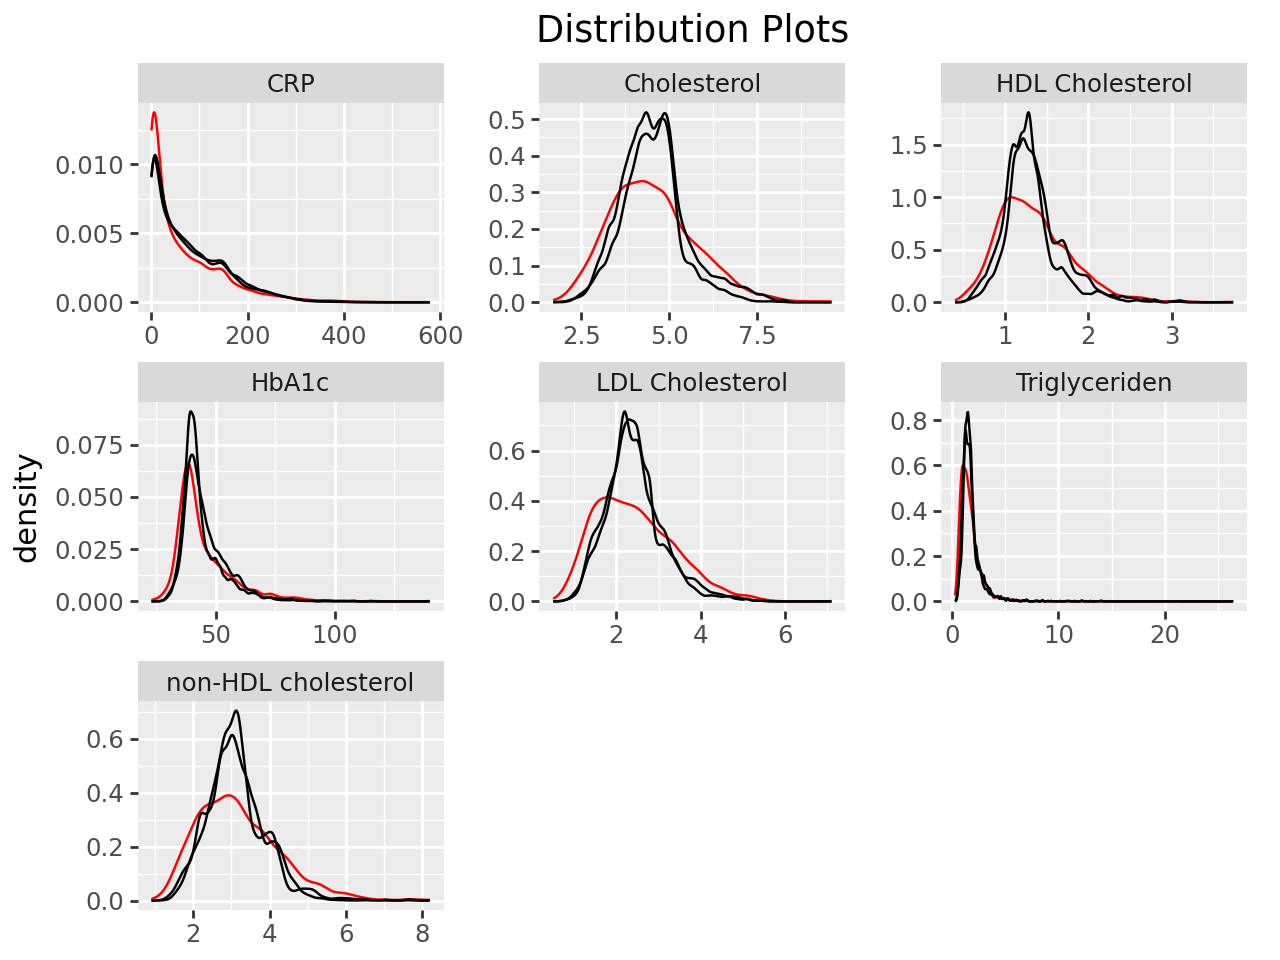

In [ ]:
ker.plot_imputed_distributions()